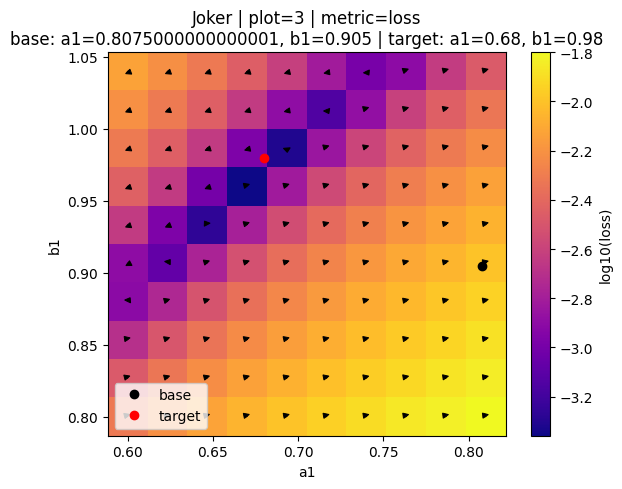

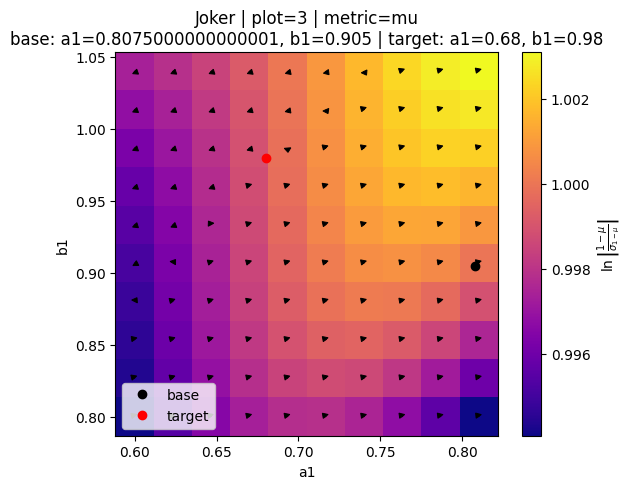

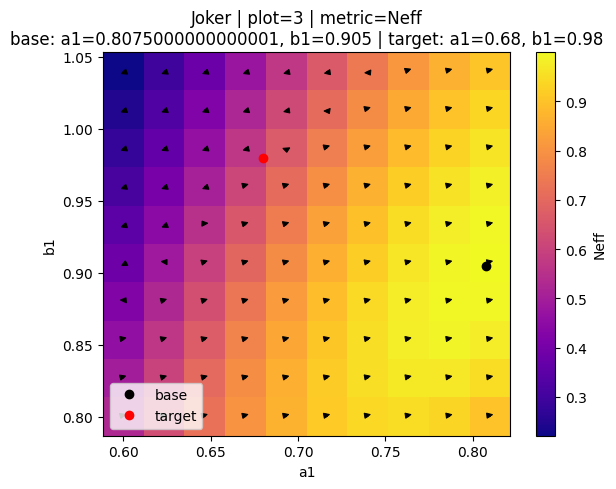

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Choose observable & plot
# =========================
observable = 'Joker'   # <-- set this
plot_nm    = '3'            # <-- and this ('0', '1', ...)

# =========================
# Configurations per observable
# =========================
plot_configs = {
    'Joker': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905),   # (a_d, b_d)
            'target': (0.68, 0.98),    # (a_d, b_d)
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905),   # (a_d, b_d)
            'target': (0.68, 0.98),    # (a_d, b_d)
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905),   # (a_d, b_d)
            'target': (0.68, 0.98),    # (a_d, b_d)
        },
        '4': {
            'scale': 5e3,
            'head_width': 0.0008,
            'head_length': 0.0008,
            'base':   (0.68, 0.98),   # (a_d, b_d)
            'target': (0.68, 0.98),    # (a_d, b_d)
        },
    },
    # Add others as needed...
}

def get_config(obs: str, pnm: str):
    try:
        return plot_configs[obs][pnm]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', plot_nm='{pnm}'. "
                         f"Available: {list(plot_configs.keys())}")

config = get_config(observable, plot_nm)

# =========================
# Paths
# =========================
base_dir = f"temp_results/Flow_map/2D/{observable}"
out_folder = f"temp_results/Flow_map_nD/plots/{observable}"
os.makedirs(out_folder, exist_ok=True)

# =========================
# Load data
# =========================
gradients      = np.load(os.path.join(base_dir, f'gradients_{plot_nm}.npy'))
loss_grid      = np.load(os.path.join(base_dir, f'loss_grid_{plot_nm}.npy'))
mu_sigmamu     = np.load(os.path.join(base_dir, f'mu_{plot_nm}.npy'))
Neff           = np.load(os.path.join(base_dir, f'Neff_{plot_nm}.npy'))
params_grid    = np.load(os.path.join(base_dir, f'params_grid_{plot_nm}.npy'))
ordered_params = np.load(os.path.join(base_dir, f'ordered_params_{plot_nm}.npy'))

# Ensure ordered_params are strings (handle bytes from npy if present)
def _to_str_list(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode('utf-8', errors='ignore'))
        else:
            out.append(str(x))
    return out

ordered_params = _to_str_list(ordered_params)

# Unpack weight metrics
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# =========================
# Metrics to display
# =========================
metrics = {
    'loss': {
        'values': lambda: np.log10(loss_grid),
        'label':  'log10(loss)'
    },
    'mu':   {
        'values': lambda: mu,
        'label':  r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"
    },
    'Neff': {
        'values': lambda: Neff,
        'label':  'Neff'
    },
}

# =========================
# Build grid in (a_d, b_d)
# =========================
a_vals = np.unique(params_grid[:, 0])
b_vals = np.unique(params_grid[:, 1])
A, B   = np.meshgrid(a_vals, b_vals, indexing='ij')

for metric_key, metric in metrics.items():
    vals = metric['values']()

    # Safety check
    expected_size = len(a_vals) * len(b_vals)
    if vals.size != expected_size:
        raise ValueError(
            f"Inconsistent grid: metric size={vals.size}, "
            f"expected {expected_size} (len(a)={len(a_vals)} * len(b)={len(b_vals)})"
        )

    Z = vals.reshape(len(a_vals), len(b_vals))

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    pcm = plt.pcolormesh(A, B, Z, shading='auto', cmap='plasma')
    plt.colorbar(pcm, label=metric['label'])

    # Overlay gradient arrows (negative = descent)
    for (x, y), g in zip(params_grid, gradients):
        dx = -g[0] / config['scale']
        dy = -g[1] / config['scale']
        plt.arrow(
            x, y, dx, dy,
            head_width=config['head_width'],
            head_length=config['head_length'],
            fc='k', ec='k', linewidth=0.7
        )

    # Mark base & target
    bx, by = config['base']
    tx, ty = config['target']
    plt.plot(bx, by, 'o', color='black', markersize=6, label='base')
    plt.plot(tx, ty, 'o', color='red',   markersize=6, label='target')

    # Titles and labels
    title = (
        f"{observable} | plot={plot_nm} | metric={metric_key}\n"
        f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by} | "
        f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}"
    )
    plt.title(title)
    plt.xlabel(ordered_params[0])
    plt.ylabel(ordered_params[1])
    plt.legend(loc='lower left')
    plt.tight_layout()

    # Save
    fname = f'{observable}_plot{plot_nm}_{metric_key}.png'
    plt.savefig(os.path.join(out_folder, fname), dpi=300, bbox_inches='tight')
    # plt.close()
